Author: Daniel Abadjiev  
Date: October 17, 2025  
Description: A runner notebook for ASICModel.py to try it out. 
Eventually this should be made into a script, or added to a generic script.

In [1]:

import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import ASICModel

2026-06-10 05:51:18.164445: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-10 05:51:18.166311: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 05:51:18.203279: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-10 05:51:18.203922: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-10 05:51:19.016349: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2026-06-10 05:51:21.265430: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-06-10 05:51:21.271554: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# model1 = ASICModel.ModelASIC(tfRecordFolder="/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V3_May/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/")
tfRecordFolder="/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized/"
model1 = ASICModel.ModelASIC(tfRecordFolder=tfRecordFolder)
# model1.buildModel()
# model1.makeUnquantizedModel()
# model1.loadTfRecords()
# model1.makeQuantizedModel()
# model1.trainModel(epochNumber=10)
# model1.validation_generator

=== Running Complete ASIC Model Pipeline with Quantization Testing ===
All results will be saved to: ASIC Model_results_20260610_043652/
1. Loading TFRecords...
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41

2. Testing Non-quantized Model...
2a. Building Unquantized model...
runUnquantized set False, so skipping unquantized model

3. Testing 4-bit Quantized Model...
3a. Creating fresh data generators...
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 162
Validation generator length: 41
I'm not sure that's actually necessary
3b. Building 4-bit quantized model...
Building Model ASIC quantized_4w0i...
Model: "ModelASIC_quantized4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inVectAsic (InputLayer)     [(None, 16)]              0         
                                                                 
 q_input_cluster (QActivati  (None, 16)                0         
 on)                                                             
                                                                 
 dense1 (QDenseBatchnorm)    (None, 58)                1219      
                                                                 
 relu1 (QActivation)         (None, 58)                0         
                                                                 
 dense2 (QDense)             (None, 3)                 177       


/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_size', 'z_global', 'y_profile', 'x_profile', 'cluster', 'y_local', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


162/162 [==============================] - ETA: 0s - loss: 1.0137 - sparse_categorical_accuracy: 0.5607
[Gradient Monitor] Epoch 0:
  Mean grad norm: 1.44e-01
  Max grad norm: 4.25e-01
  Min grad norm: 2.48e-07


162/162 [==============================] - 18s 110ms/step - loss: 1.0137 - sparse_categorical_accuracy: 0.5607 - val_loss: 0.7399 - val_sparse_categorical_accuracy: 0.7067
✓ ASIC Model quantized_4w0i training completed!

[Gradient Statistics Summary for quantized_4w0i]
  Final mean gradient norm: 1.44e-01
  Final max gradient norm: 4.25e-01
  Final min gradient norm: 2.48e-07
3e. Evaluating 4-bit quantized model...
Evaluating ASIC Model [quantized_4w0i]...
41/41 [==============================] - 4s 87ms/step
<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.7417
  Test Accuracy: 0.7099
  ROC AUC: 0.7099

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 1.0000
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data A

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Training history plot saved to ASIC Model_results_20260610_043652/plots/4bit/ASIC Model_training_history.png


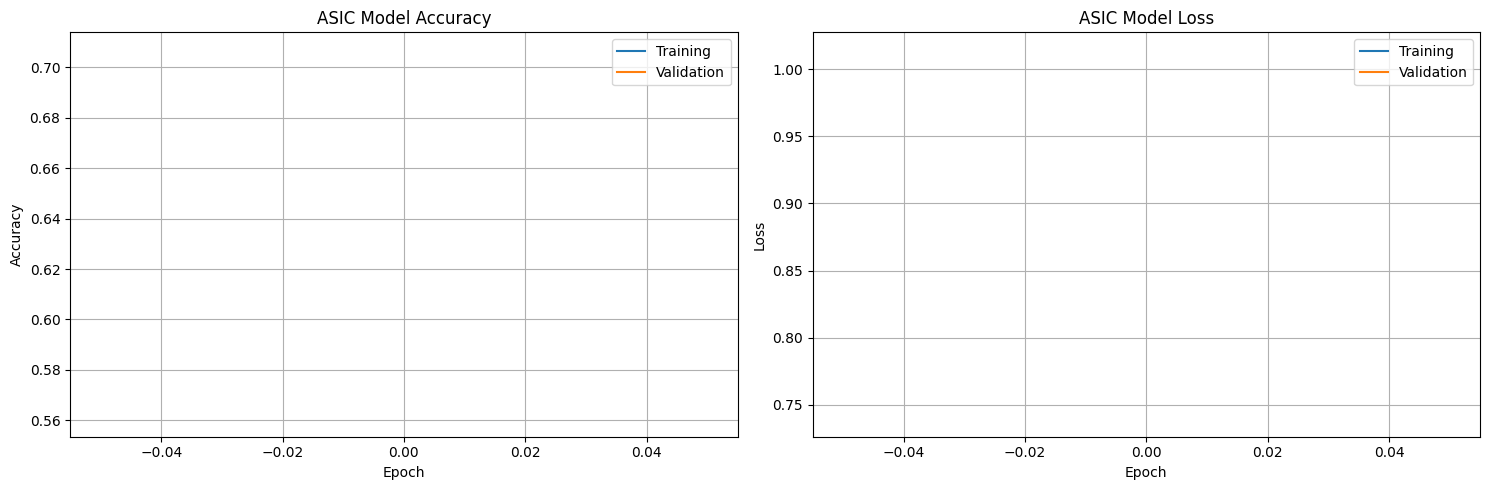

ROC curve plot saved to ASIC Model_results_20260610_043652/plots/4bit/ASIC Model_roc_curve.png


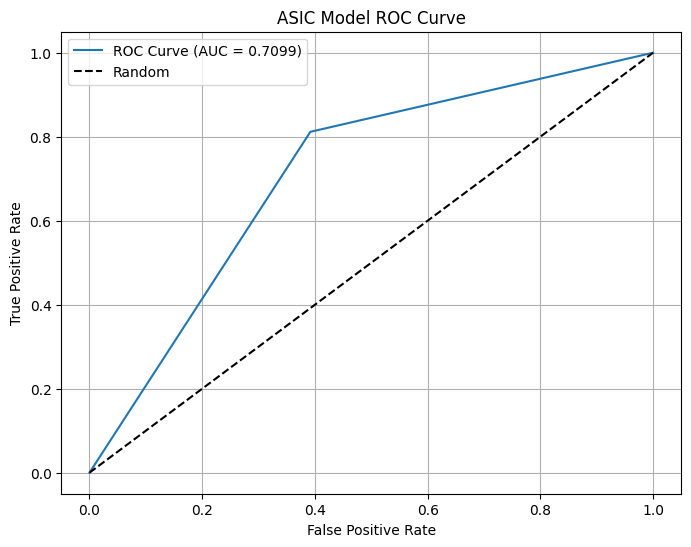


4. Results Summary:
Model Type      Bits     Accuracy   Loss       ROC AUC    BkgRej@90%   BkgRej@98%   BkgRej@99%  
------------------------------------------------------------------------------------------------------------------------
quantized       4        0.7099     0.7417     0.7099     0.0000       0.0000       0.0000      

BEST CONFIGURATION:
Model: quantized
Bits: 4-bit
Accuracy: 0.7099
ROC AUC: 0.7099

Results saved to: ASIC Model_results_20260610_043652/quantization_results.csv

=== ASIC Model Quantization Pipeline Completed! ===
All outputs saved to: ASIC Model_results_20260610_043652/
  - Models: ASIC Model_results_20260610_043652/models/
  - Plots: ASIC Model_results_20260610_043652/plots/
  - Results CSV: ASIC Model_results_20260610_043652/quantization_results.csv


[{'model_type': 'quantized',
  'weight_bits': 4,
  'integer_bits': 0,
  'test_accuracy': 0.7098575830459595,
  'test_loss': 0.7417287826538086,
  'roc_auc': 0.7098575622617093,
  'bkg_rej_90pct': 0.0,
  'bkg_rej_98pct': 0.0,
  'bkg_rej_99pct': 0.0,
  'model_path': 'ASIC Model_results_20260610_043652/models/ASIC Model_quantized_4bit.h5'}]

In [3]:
# model1.trainQuantizedModel(numEpochs=10)
model1.runAllStuff(numEpochs=1,runUnquantized = False)

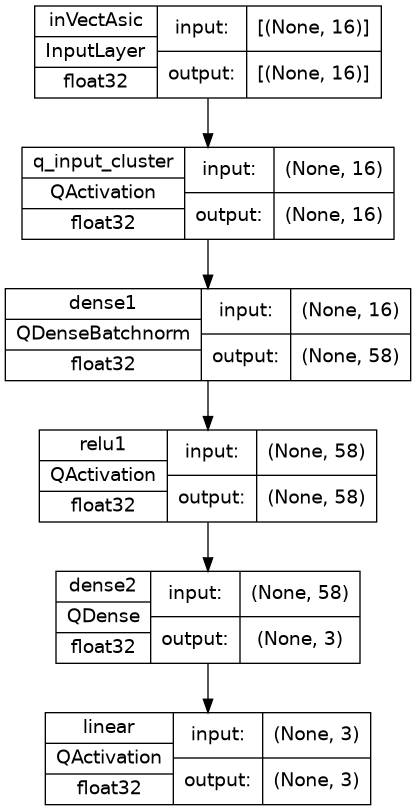

In [8]:
import tensorflow as tf
tf.keras.utils.plot_model(model1.models["quantized_4w0i"], show_dtype=True, 
                       show_layer_names=True, show_shapes=True,)
                    #    to_file='model.png')

In [9]:
model1.reportQuantizedBrejSeff()
# model1.plotModel(config_name = "quantized_4w0i")

Background rejection: 0.6080618973758923 at signal efficiency 0.8116532271475263.
Note: Since model is highly quantized, other signal efficiencies are not accessible, but can check roc_curve


In [14]:
model1.evaluate(config_name="quantized_4w0i",predictionPlots=True)

Evaluating ASIC Model [quantized_4w0i]...
 3/41 [=>............................] - ETA: 2s

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 77ms/step


KeyboardInterrupt: 

In [6]:
predictions = model1.models["quantized_4w0i"].predict(model1.validation_generator, verbose=1)
# predictions = model1.models["Unquantized"].predict(model1.validation_generator, verbose=1)
import numpy as np
true_labels = np.concatenate([y for _, y in model1.validation_generator])

if predictions.shape[1]>1:
    predictions = np.argmax(predictions,axis=1)

 3/41 [=>............................] - ETA: 2s

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_profile', 'cluster', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 76ms/step


In [7]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(true_labels, predictions.ravel())
print(fpr,tpr)

[0.         0.29880178 1.        ] [0.         0.88300815 1.        ]


In [ ]:
model1.models["quantized_4w0i"].save("./modelATest4hls.h5")

/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### starting from saved model  

In [10]:
# %pip install particle
import varPredPlotUtils
filepath = "./modelATest4hls.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260609_101715/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260608_104730/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260608_104730/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260608_100403/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260609_105104/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260610_044128/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260610_055759/models/ASIC Model_quantized_4bit.h5"
filepath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/daniel/ASIC Model_results_20260610_065406/models/ASIC Model_quantized_4bit.h5"
from Model_Classes import GradientMonitor, WarmupThenDecay
co = {"GradientMonitor": GradientMonitor, "WarmupThenDecay": WarmupThenDecay}
quantizedModel = varPredPlotUtils.loadQModel(filepath,None,co=co) # get ValueError: Unknown decay: 'WarmupThenDecay'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

# filepathOther = '/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Final_Results/model3_fin_results/model3_10bit_normalised_selected/pareto_primary/model_trial_084.h5'
# filepathOther = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Final_Results/model2.5_fin_results/model2.5_10bit_normalised_selected"
# filepathOther =  '/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Final_Results/model1_fin_results/8w0i_i10_sigmoid/hp4q_model_trial_008.h5'
# filepathOther = '/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Final_Results/model2.5_fin_results/model2.5_8bit_normalised_selected/model_trial_065.h5'#, '/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/eric/Final_Results/model2.5_fin_results/model2.5_8bit_normalised_selected/model_trial_043.h5'
# quantizedModel = varPredPlotUtils.loadQModel(filepathOther,None, co = co) 
# # quantizedModel = model1.models["quantized_4w0i"]
model, predictions,modelType = varPredPlotUtils.getModelAndPredict(quantizedModel, tfRecordFolder=tfRecordFolder)
import numpy as np
true_labels = np.concatenate([y for _, y in model.validation_generator])

if predictions.shape[1]>1:
    predictions = np.argmax(predictions,axis=1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V4_June/TF_Records/filtering_records16384_data_shuffled_single_bigData_normalized//tfrecords_validation/
Using batch_size=16384 to match TFRecord format


/home/dabadjiev/miniconda3/envs/miscGithubEnviro/lib/python3.10/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['x_size', 'z_global', 'y_profile', 'x_profile', 'cluster', 'y_local', 'nPix', 'x_local', 'nModule'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


Training generator length: 162
Validation generator length: 41
Evaluating ASIC Model [justThisOne]...
41/41 [==============================] - 3s 78ms/step
Data rate at fpr 0.2285353191772414 and threshold [1]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.3368
  Test Accuracy: 0.8725
  ROC AUC: 0.8725

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.7715 (FPR = 0.228535), Back Data Accep = 0.1588
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 1.0000
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 1.0000
41/41 [==============================] - 3s 77ms/step


In [12]:
model.reportQuantizedBrejSeff()

Background rejection: 0.7714646808227585 at signal efficiency 0.9735775123132602.
Note: Since model is highly quantized, other signal efficiencies are not accessible, but can check roc_curve


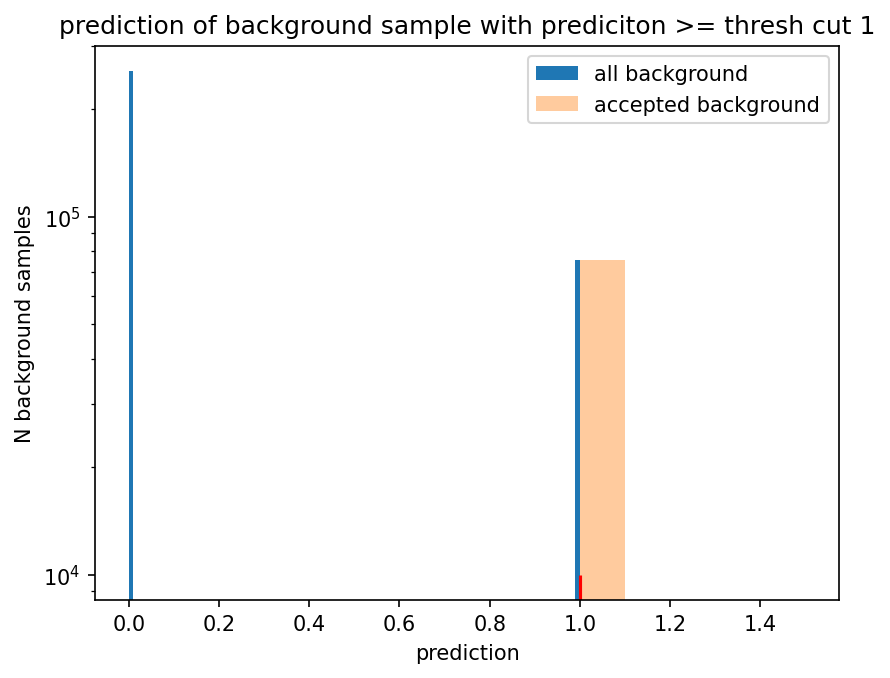


accepted background samples:  75586
total background samples:  330741
backgorund acceptance:  0.2285353191772414
Total background pixel count:  2000084.0
Accepted background pixel count:  317572.0
Data rate of background acceptance:  0.15877934


(317572.0, 2000084.0, 0.15877934)

In [13]:
import dataRateUtils
threshVal = 1
dataRateUtils.genNpixAndGetDataRate(model,predictions.ravel(),cut=threshVal, doPrintExtra = True, doPlot = True)

Evaluating ASIC Model [justThisOne]...
41/41 [==============================] - 3s 78ms/step
Data rate at fpr 0.2285353191772414 and threshold [1]
Data rate at fpr 1.0 and threshold [0]
Data rate at fpr 1.0 and threshold [0]
✓ ASIC Model evaluation completed!
  Test Loss: 0.3368
  Test Accuracy: 0.8725
  ROC AUC: 0.8725

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.7715 (FPR = 0.228535), Back Data Accep = 0.1588
    @ 98% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 1.0000
    @ 99% signal efficiency: Bkg Rej = 0.0000 (FPR = 1.000000), Back Data Accep = 1.0000
['x_local', 'nModule', 'nPix', 'y_local', 'z_global']


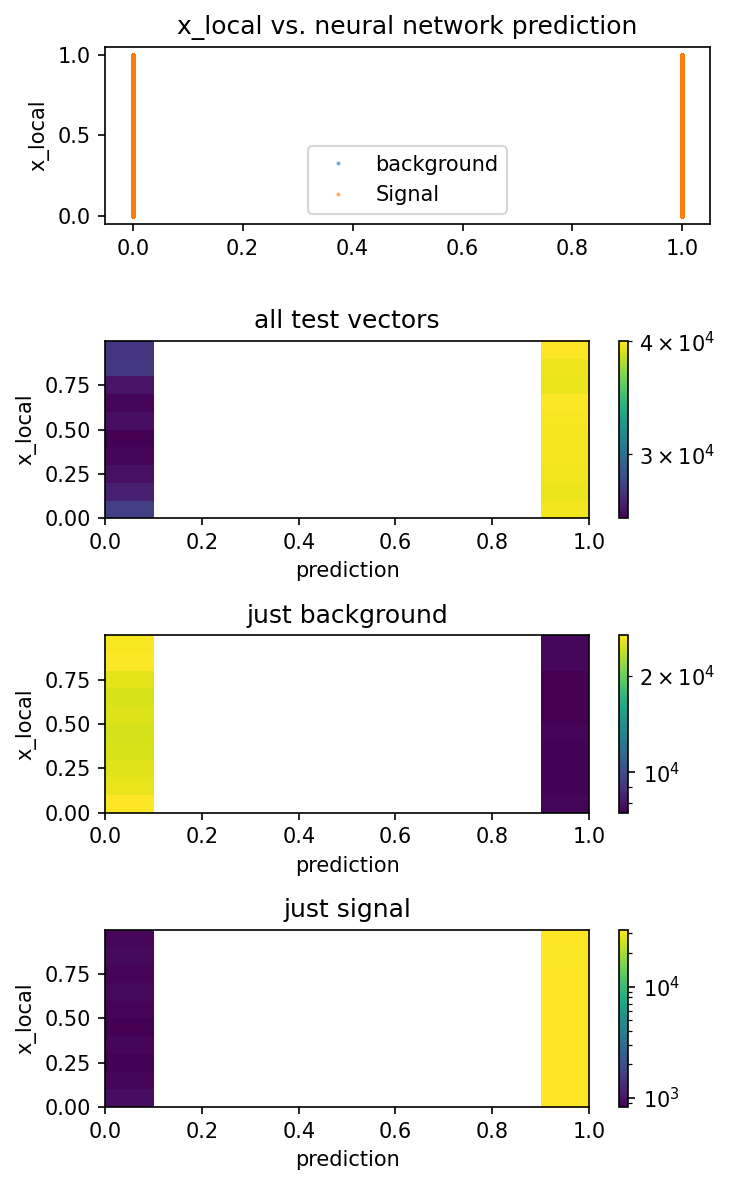

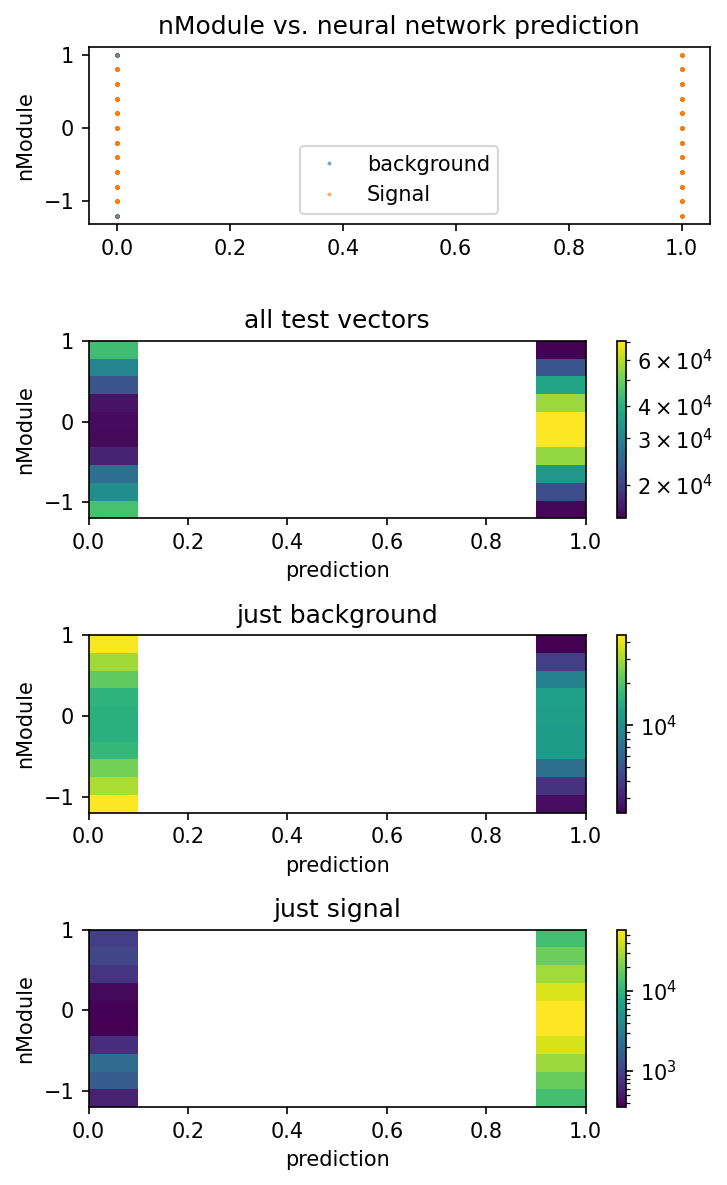

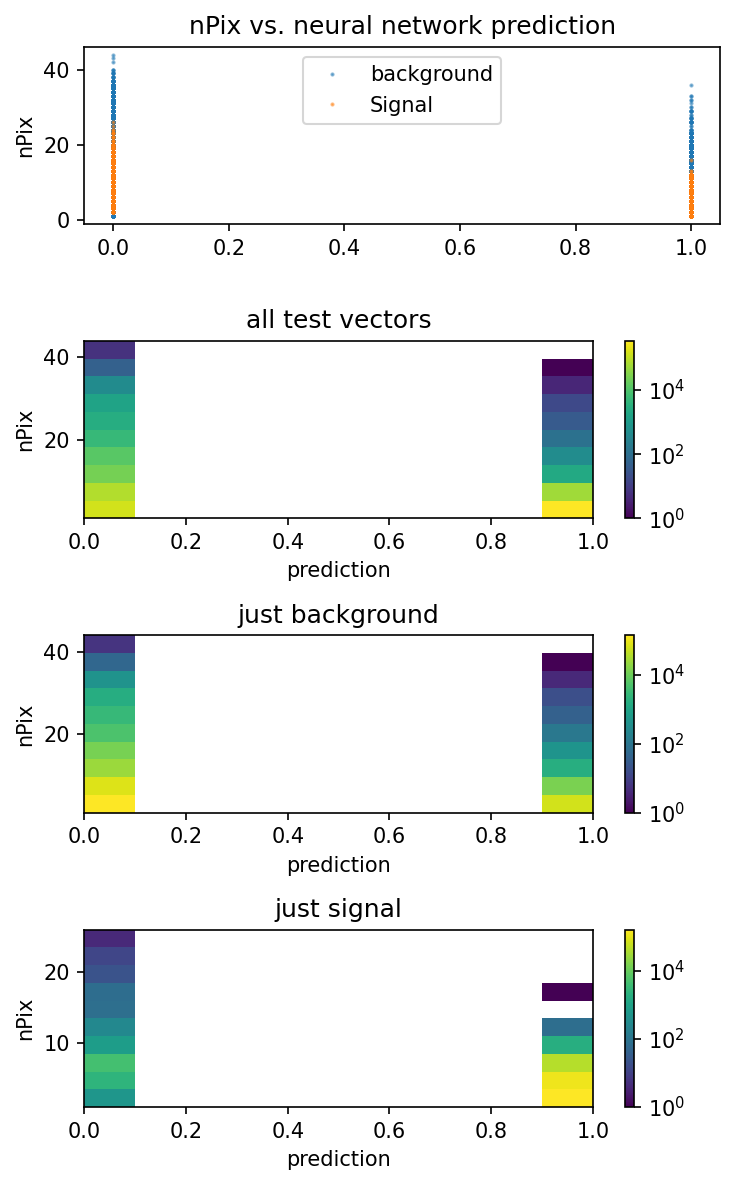

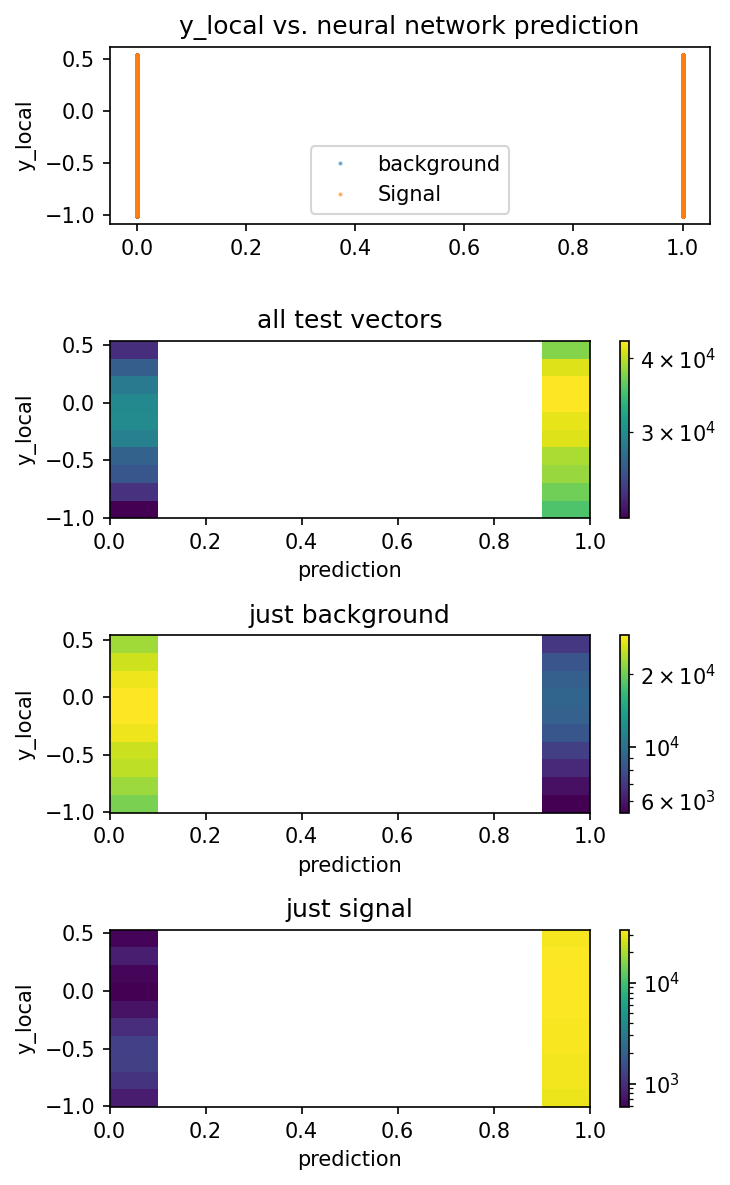

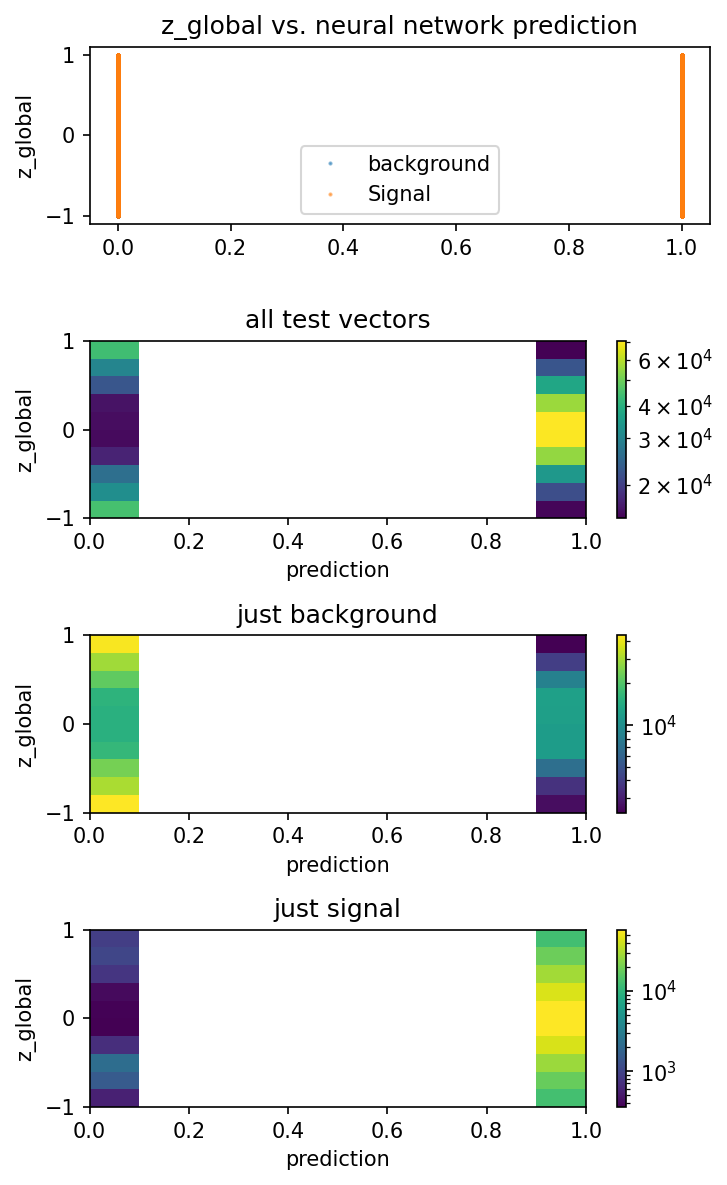

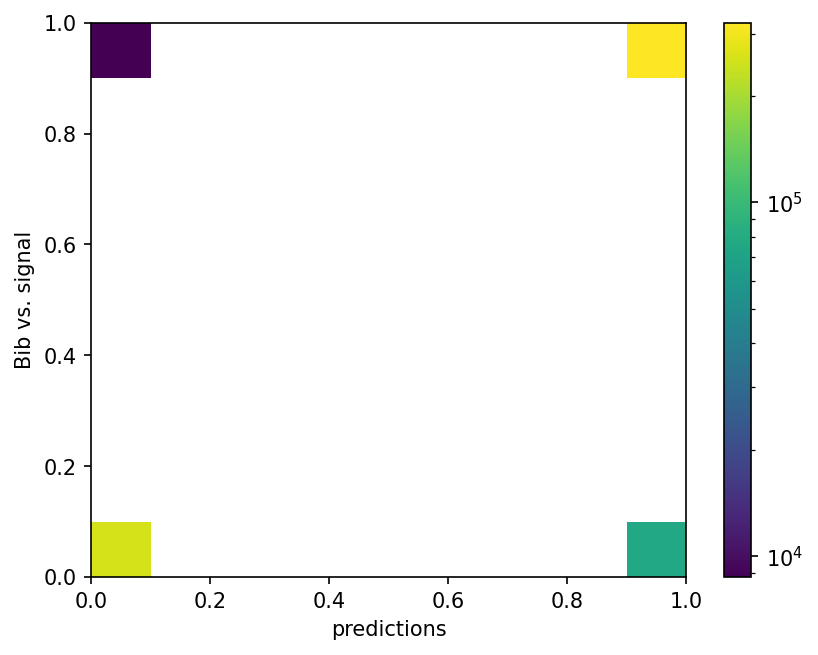

{'test_loss': 0.3367992341518402,
 'test_accuracy': 0.8725211024284363,
 'roc_auc': 0.8725210965680092,
 'fpr': [0.0, 0.2285353191772414, 1.0],
 'tpr': [0.0, 0.9735775123132602, 1.0],
 'thresholds': [2, 1, 0],
 'bkg_rej_at_90pct': 0.7714646808227585,
 'fpr_at_90pct': 0.2285353191772414,
 'bkg_rej_at_98pct': 0.0,
 'fpr_at_98pct': 1.0,
 'bkg_rej_at_99pct': 0.0,
 'fpr_at_99pct': 1.0,
 'numBackPixesPostFilter': [317572.0, 2000084.0, 2000084.0],
 'numBackPixesTotal': [2000084.0, 2000084.0, 2000084.0],
 'numBackPixesRejRatio': [0.15877934, 1.0, 1.0]}

In [14]:
# model.evaluate(config_name="quantized_4w0i",predictionPlots=True)
model.evaluate(config_name="justThisOne",predictionPlots=True)